# Probe Detector -- Analyze Trained Checkpoints

**Analysis only.** Reads the 3 candidate checkpoints produced by
`training/train_colab.ipynb` (YOLOv8 n/s/m) plus the out-of-the-box
baseline, evaluates all of them on val, compares them in charts, auto-picks
the winner by AP@0.5, copies it to `weights/best.pt`, and runs the final
one-time test-split check.

(An earlier version of this project also planned a horizontal-flip
augmentation ablation per variant -- training 6 candidates instead of 3.
Dropped for time: doubling the training runs wasn't worth it given the
n/s/m comparison alone was already decisive. Noted as future work in the
report rather than left half-done here.)

No GPU needed (evaluation runs on CPU, matching real deployment) and no
LaMa dependency (the dataset is pulled pre-built from Drive, not
regenerated) -- this is deliberately much lighter than the training
notebook, so it's cheap to re-run after any change to `evaluate.py` or
`compare_results.py`. **You can pick a CPU-only Colab runtime for this
notebook** (Runtime > Change runtime type > CPU) to save GPU quota; nothing
here benefits from a GPU. It can also just be run locally: `python
analyze_results.py --candidates ...` in the project's `.venv`, once the
`weights/` and `yolo_dataset/` folders are downloaded from Drive.

## 1. Mount Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT_DIR = '/content/drive/MyDrive/Probe_detector'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Install dependencies

Just `ultralytics` -- no `simple-lama-inpainting`, since the dataset is copied pre-built from Drive, not regenerated.

In [8]:
!pip install -q ultralytics

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
The folder you are executing pip from can no longer be found.


## 3. Get the project, dataset, and trained weights onto local VM disk

Same zip-extraction approach as the training notebook for the code, plus
copying `yolo_dataset/` and `weights/` from Drive (both written there by
`train_colab.ipynb`) instead of rebuilding/retraining them.

In [9]:
import shutil
import zipfile
from pathlib import Path

LOCAL_PROJECT_DIR = Path('/content/Probe_detector')
DRIVE_ZIP_PATH = Path('/content/drive/MyDrive/Probe_detector.zip')

if LOCAL_PROJECT_DIR.exists():
    shutil.rmtree(LOCAL_PROJECT_DIR)

if DRIVE_ZIP_PATH.exists():
    LOCAL_PROJECT_DIR.mkdir(parents=True)
    with zipfile.ZipFile(DRIVE_ZIP_PATH) as zf:
        zf.extractall(LOCAL_PROJECT_DIR)
    print(f'Extracted {DRIVE_ZIP_PATH} -> {LOCAL_PROJECT_DIR}')
else:
    raise FileNotFoundError(f'{DRIVE_ZIP_PATH} not found on Drive -- upload the project first.')

%cd {LOCAL_PROJECT_DIR}

drive_yolo_dataset = Path(DRIVE_PROJECT_DIR) / 'yolo_dataset'
if not drive_yolo_dataset.exists():
    raise FileNotFoundError(
        f'{drive_yolo_dataset} not found on Drive. This notebook is deliberately lightweight '
        'and does not build the dataset itself (no LaMa here). Run steps 1-4 of '
        'train_colab.ipynb once (mount, install, extract, build dataset -- you can skip '
        'step 5, training, if you already have weights) to populate it on Drive, then '
        're-run this cell.'
    )
shutil.copytree(drive_yolo_dataset, LOCAL_PROJECT_DIR / 'yolo_dataset', dirs_exist_ok=True)
print('Copied yolo_dataset/ from Drive')

shutil.copytree(Path(DRIVE_PROJECT_DIR) / 'weights', LOCAL_PROJECT_DIR / 'weights', dirs_exist_ok=True)
print('Copied weights/ from Drive')
print('Available candidates:', sorted(p.name for p in (LOCAL_PROJECT_DIR / 'weights').iterdir() if p.is_dir()))

Extracted /content/drive/MyDrive/Probe_detector.zip -> /content/Probe_detector
/content/Probe_detector
Copied yolo_dataset/ from Drive
Copied weights/ from Drive
Available candidates: ['yolov8m', 'yolov8n', 'yolov8s']


## 4. Evaluate, compare, auto-pick the winner, and run the final test check

All of this is `analyze_results.py` (see its docstring) -- adjust
`--candidates` if you trained under different names or only a subset.

In [10]:
!python analyze_results.py --candidates yolov8n yolov8s yolov8m


=== baseline ===
Evaluating on val: 51 positive + 51 negative images...
{
  "weights": "yolov8n.pt",
  "split": "val",
  "localization": {
    "n_positive_images": 51,
    "mean_iou_top_detection": 0.37187710410802005,
    "operating_conf_threshold": 0.35,
    "iou_match_threshold": 0.5,
    "precision_at_conf": 0.21428571428571427,
    "recall_at_conf": 0.058823529411764705,
    "f1_at_conf": 0.09230769230769231,
    "ap_at_iou_0.5": 0.12864926134189425,
    "fp_calibrated_threshold": 0.84,
    "recall_at_fp_calibrated_threshold": 0.0
  },
  "no_probe_behavior": {
    "n_negative_images": 51,
    "fp_target": 0.05,
    "target_reached": true,
    "suggested_threshold": 0.84,
    "achieved_fp_rate_at_suggested_threshold": 0.0392156862745098
  },
  "runtime": {
    "device": "cpu",
    "cpu_model": "x86_64",
    "n_images_timed": 50,
    "mean_ms": 141.30654545988364,
    "median_ms": 148.90814300088095,
    "p90_ms": 165.32600600112346,
    "fps": 7.076813014892477
  },
  "roc_auc": 0

## 5. View the comparison chart

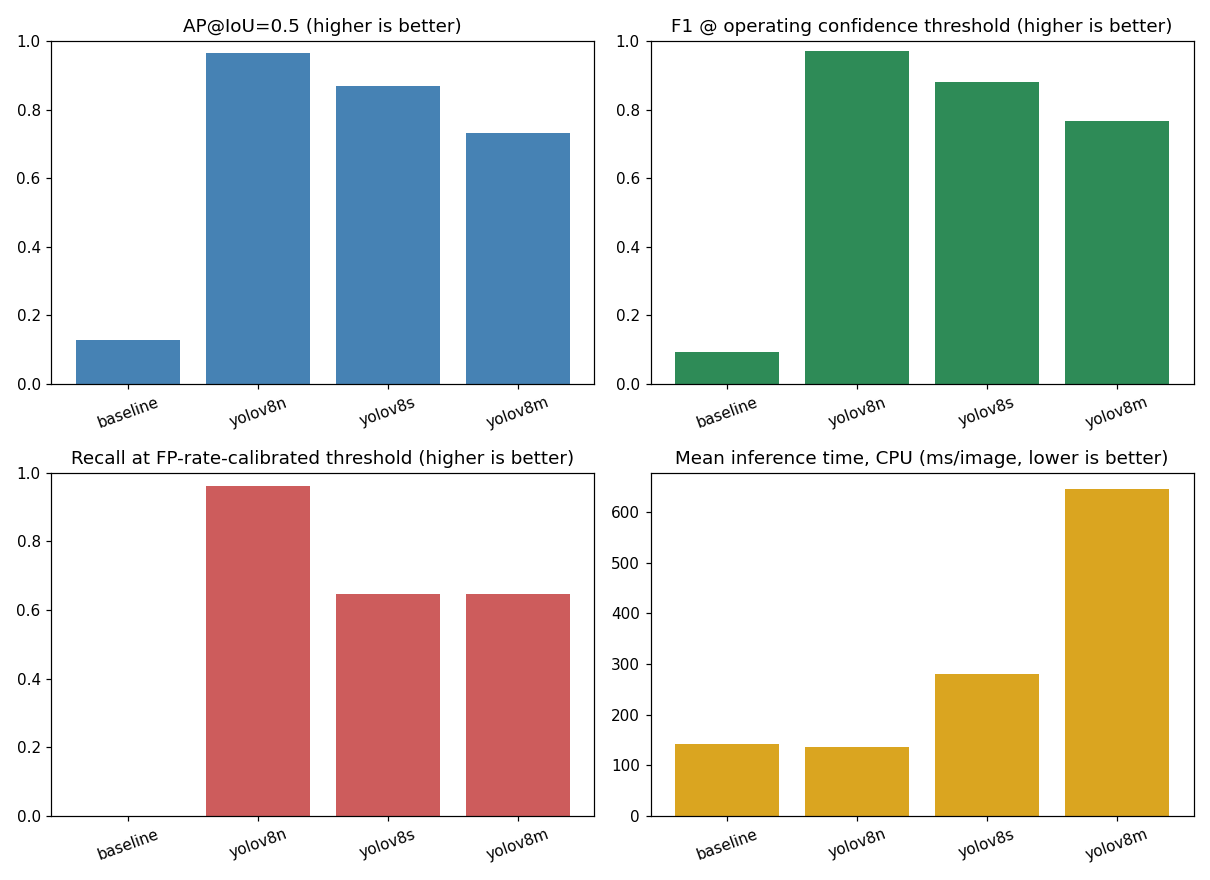

In [11]:
from IPython.display import Image, display
display(Image('report/figures/model_comparison.png'))

## 6. Sync results and the final chosen weights back to Drive

Everything in step 4 was written to local disk only, same caveat as always.

In [12]:
shutil.copytree(LOCAL_PROJECT_DIR / 'report', Path(DRIVE_PROJECT_DIR) / 'report', dirs_exist_ok=True)
print('Synced report/ -> Drive')

dst = Path(DRIVE_PROJECT_DIR) / 'weights' / 'best.pt'
dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy(LOCAL_PROJECT_DIR / 'weights' / 'best.pt', dst)
print('Synced weights/best.pt -> Drive')

Synced report/ -> Drive
Synced weights/best.pt -> Drive
